📊 Dataset Statistics
count     79.000000
mean     123.873418
std       26.803830
min       60.000000
25%      107.500000
50%      134.000000
75%      145.000000
max      150.000000
Name: Count, dtype: float64

Min: 60
Max: 150
Median: 134.0
Std Dev: 26.80383013608871
Imbalance Ratio (max/min): 2.5


C:\Users\Harsh\AppData\Local\Temp\ipykernel_26432\837489855.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


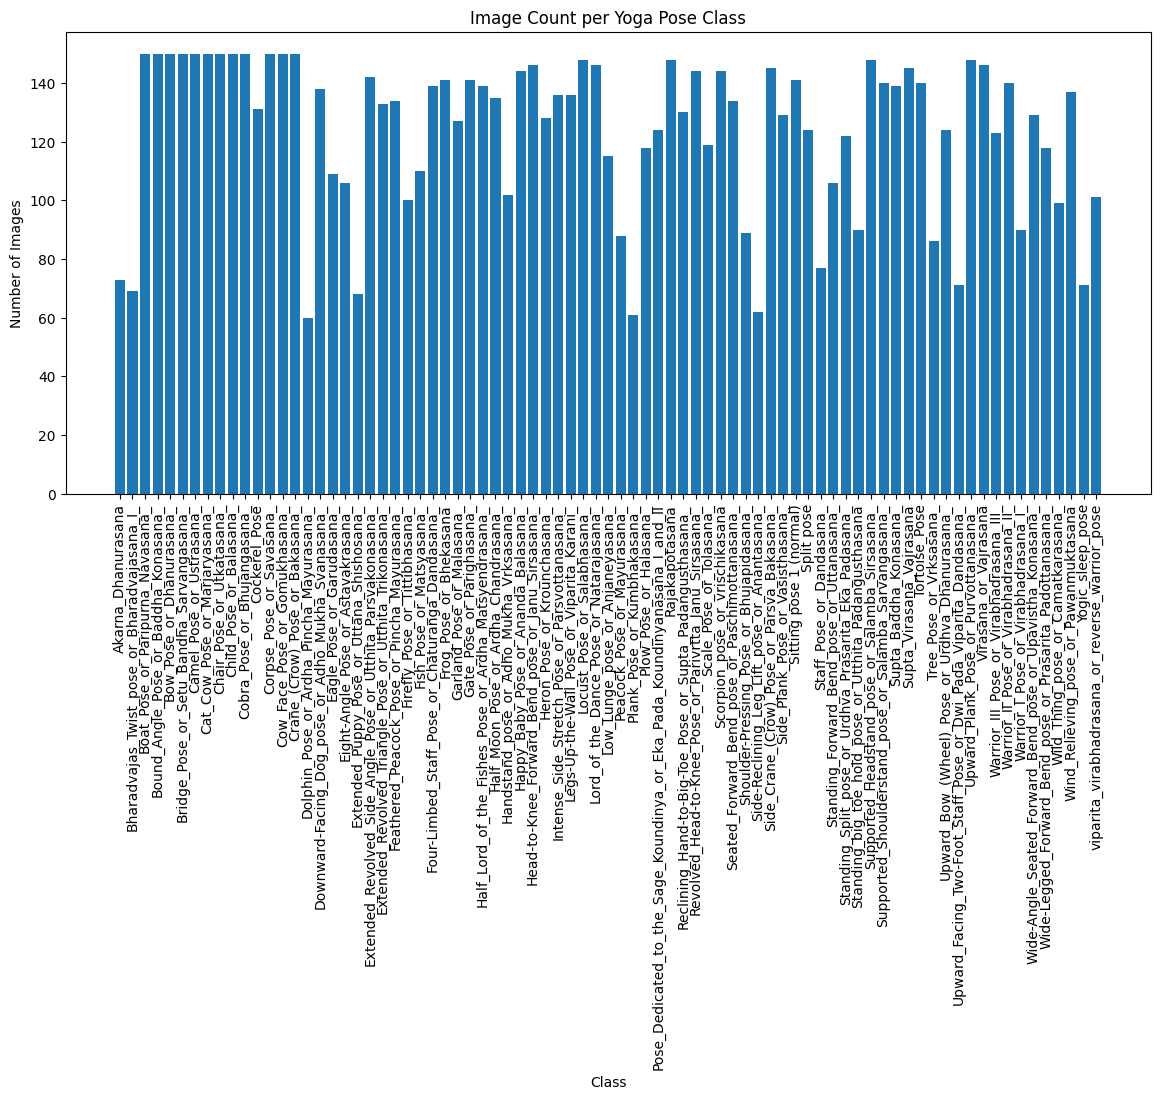

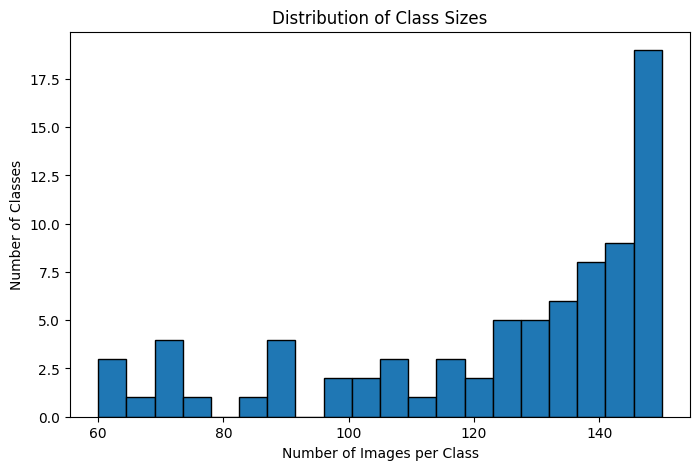

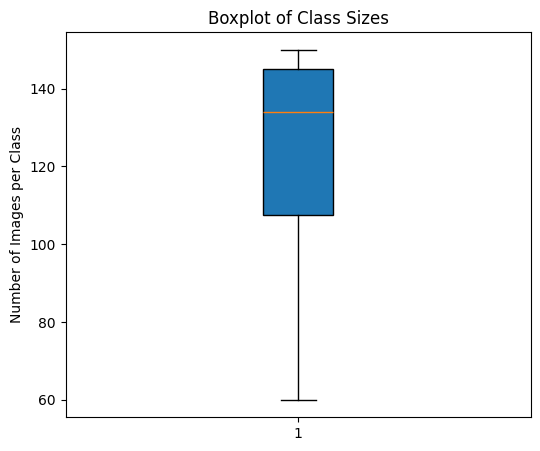


✅ Class distribution saved to class_distribution.csv


In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

BASE_DIR = "../data/images"

# --- Collect data ---
class_counts = {}
for cls in sorted(os.listdir(BASE_DIR)):
    cls_path = os.path.join(BASE_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
        class_counts[cls] = count

df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])

# --- Summary statistics ---
print("📊 Dataset Statistics")
print(df["Count"].describe())
print("\nMin:", df["Count"].min())
print("Max:", df["Count"].max())
print("Median:", df["Count"].median())
print("Std Dev:", df["Count"].std())
print("Imbalance Ratio (max/min):", round(df["Count"].max() / df["Count"].min(), 2))

# --- Plot 1: Bar chart (per class) ---
plt.figure(figsize=(14,6))
plt.bar(df["Class"], df["Count"])
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Count per Yoga Pose Class")
plt.tight_layout()
plt.show()

# --- Plot 2: Histogram (distribution of class sizes) ---
plt.figure(figsize=(8,5))
plt.hist(df["Count"], bins=20, edgecolor="black")
plt.xlabel("Number of Images per Class")
plt.ylabel("Number of Classes")
plt.title("Distribution of Class Sizes")
plt.show()

# --- Plot 3: Boxplot ---
plt.figure(figsize=(6,5))
plt.boxplot(df["Count"], vert=True, patch_artist=True)
plt.ylabel("Number of Images per Class")
plt.title("Boxplot of Class Sizes")
plt.show()

# --- Optional: Save summary to CSV ---
df.to_csv("class_distribution.csv", index=False)
print("\n✅ Class distribution saved to class_distribution.csv")


In [3]:
import os
import shutil
import random

OUT_DIR = "../data/split"     # new split folder
TRAIN_RATIO = 0.8          # 80% train, 20% test
random.seed(42)            # reproducibility

train_dir = os.path.join(OUT_DIR, "train")
test_dir = os.path.join(OUT_DIR, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for cls in sorted(os.listdir(BASE_DIR)):
    cls_path = os.path.join(BASE_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    files = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
    random.shuffle(files)

    split_idx = int(len(files) * TRAIN_RATIO)
    train_files, test_files = files[:split_idx], files[split_idx:]

    # --- Create class subfolders ---
    train_cls_path = os.path.join(train_dir, cls)
    test_cls_path = os.path.join(test_dir, cls)
    os.makedirs(train_cls_path, exist_ok=True)
    os.makedirs(test_cls_path, exist_ok=True)

    # --- Copy files ---
    for f in train_files:
        shutil.copy2(os.path.join(cls_path, f), os.path.join(train_cls_path, f))
    for f in test_files:
        shutil.copy2(os.path.join(cls_path, f), os.path.join(test_cls_path, f))

    print(f"✅ {cls}: {len(train_files)} train, {len(test_files)} test")

    
print("\n🎯 Train/Test split completed!")
print(f"Train data in: {train_dir}")
print(f"Test data in: {test_dir}")



✅ Akarna_Dhanurasana: 58 train, 15 test
✅ Bharadvajas_Twist_pose_or_Bharadvajasana_I_: 55 train, 14 test
✅ Boat_Pose_or_Paripurna_Navasana_: 120 train, 30 test
✅ Bound_Angle_Pose_or_Baddha_Konasana_: 120 train, 30 test
✅ Bow_Pose_or_Dhanurasana_: 120 train, 30 test
✅ Bridge_Pose_or_Setu_Bandha_Sarvangasana_: 120 train, 30 test
✅ Camel_Pose_or_Ustrasana_: 120 train, 30 test
✅ Cat_Cow_Pose_or_Marjaryasana_: 120 train, 30 test
✅ Chair_Pose_or_Utkatasana_: 120 train, 30 test
✅ Child_Pose_or_Balasana_: 120 train, 30 test
✅ Cobra_Pose_or_Bhujangasana_: 120 train, 30 test
✅ Cockerel_Pose: 104 train, 27 test
✅ Corpse_Pose_or_Savasana_: 120 train, 30 test
✅ Cow_Face_Pose_or_Gomukhasana_: 120 train, 30 test
✅ Crane_(Crow)_Pose_or_Bakasana_: 120 train, 30 test
✅ Dolphin_Pose_or_Ardha_Pincha_Mayurasana_: 48 train, 12 test
✅ Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_: 110 train, 28 test
✅ Eagle_Pose_or_Garudasana_: 87 train, 22 test
✅ Eight-Angle_Pose_or_Astavakrasana_: 84 train, 22 test
✅ E